# Makine Öğrenmesi ile Yetenek Avcılığı Sınıflandırma

## İş Problemi

Scout’lar tarafından izlenen futbolcuların özelliklerine verilen puanlara göre, oyuncuların hangi sınıfta (**average**, **highlighted**) oyuncu olduğunu tahminleme.

**Scout:** Gözlemci ya da yetenek avcısı; gelecek vadettiği düşünülen sporcuları gözlemleyerek mevcut yeteneklerini ve potansiyellerini tespit eden uzman kişi.

## Veri Seti Hikayesi

Veri seti Scoutium’dan maçlarda gözlemlenen futbolcuların özelliklerine göre scoutların değerlendirdikleri futbolcuların, maç içerisinde puanlanan özellikleri ve puanlarını içeren bilgilerden oluşmaktadır.

### scoutium_attributes.csv

**8 Değişken, 10.730 Gözlem, 527 KB**

| Değişken | Açıklama |
|---|---|
| task_response_id | Bir scoutun bir maçta bir takımın kadrosundaki tüm oyunculara dair değerlendirmelerinin kümesi |
| match_id | İlgili maçın id'si |
| evaluator_id | Değerlendiricinin (scout'un) id'si |
| player_id | İlgili oyuncunun id'si |
| position_id | İlgili oyuncunun o maçta oynadığı pozisyonun id’si |
| analysis_id | Bir scoutun bir maçta bir oyuncuya dair özellik değerlendirmelerini içeren küme |
| attribute_id | Oyuncuların değerlendirildiği her bir özelliğin id'si |
| attribute_value | Bir scoutun bir oyuncunun bir özelliğine verdiği değer (puan) |

**position_id kodları:** 1 Kaleci, 2 Stoper, 3 Sağ bek, 4 Sol bek, 5 Defansif orta saha, 6 Merkez orta saha, 7 Sağ kanat, 8 Sol kanat, 9 Ofansif orta saha, 10 Forvet

### scoutium_potential_labels.csv

**5 Değişken, 322 Gözlem, 12 KB**

| Değişken | Açıklama |
|---|---|
| task_response_id | Bir scoutun bir maçta bir takımın kadrosundaki tüm oyunculara dair değerlendirmelerinin kümesi |
| match_id | İlgili maçın id'si |
| evaluator_id | Değerlendiricinin (scout'un) id'si |
| player_id | İlgili oyuncunun id'si |
| potential_label | Bir scoutun bir maçta bir oyuncuyla ilgili nihai kararını belirten etiket (**hedef değişken**) |

## Proje Görevleri

- **Adım 1:** `scoutium_attributes.csv` ve `scoutium_potential_labels.csv` dosyalarını okutunuz.
- **Adım 2:** Okutmuş olduğumuz csv dosyalarını `merge` fonksiyonunu kullanarak birleştiriniz. (`task_response_id`, `match_id`, `evaluator_id`, `player_id` üzerinden)
- **Adım 3:** `position_id` içerisindeki Kaleci (1) sınıfını veri setinden kaldırınız.
- **Adım 4:** `potential_label` içerisindeki `below_average` sınıfını veri setinden kaldırınız. (tüm veri setinin yaklaşık %1'ini oluşturur)
- **Adım 5:** Pivot table ile her satırda bir oyuncu olacak şekilde tabloyu düzenleyiniz.
- **Adım 6:** Label Encoder ile `potential_label` kategorilerini sayısal olarak ifade ediniz.
- **Adım 7:** Sayısal değişken kolonlarını `num_cols` adıyla bir listeye atayınız.
- **Adım 8:** `num_cols` değişkenlerindeki veriyi ölçeklendirmek için StandardScaler uygulayınız.
- **Adım 9:** Minimum hata ile potansiyel etiketlerini tahmin eden bir model geliştiriniz. (roc_auc, f1, precision, recall, accuracy)
- **Adım 10:** `feature_importance` ile özelliklerin önem sıralamasını çizdiriniz.

In [1]:
# Sayısal işlemler için NumPy kütüphanesini içe aktar
import numpy as np

# Tablo (DataFrame) işlemleri için Pandas kütüphanesini içe aktar
import pandas as pd

# Görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns

# Uyarı mesajlarını bastır (çıktıyı sadeleştirir; hataları saklamaz)
import warnings
warnings.filterwarnings("ignore")

# Kategorik hedef değişkeni sayısala çevirmek için LabelEncoder
# Mesafe tabanlı modellerin (KNN, SVC, LR) adil çalışması için StandardScaler
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Çapraz doğrulama: tek bir train/test ayrımına güvenmek yerine modeli birkaç kez dener
from sklearn.model_selection import cross_validate

# Adım 9'da karşılaştırılacak sınıflandırma algoritmaları
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# --- Pandas görüntüleme ayarları ---
pd.set_option("display.max_columns", None)          # Tüm sütunlar gösterilsin
pd.set_option("display.width", 500)                 # Geniş çıktı
pd.set_option("display.float_format", lambda x: "%.3f" % x)  # Float formatı

# NOT: pandas 3.0 ile birlikte metinsel sütunlar varsayılan olarak "object" yerine
# yeni "str" (StringDtype) tipiyle okunabiliyor. Klasik dtype == "O" kontrollerinin
# bozulmaması için eski davranışı geri getiriyoruz.
pd.set_option("future.infer_string", False)

### Adım 1: `scoutium_attributes.csv` ve `scoutium_potential_labels.csv` dosyalarını okutunuz.

In [2]:
# Scoutium dosyaları virgül değil noktalı virgül (;) ile ayrılmış.
# sep=";" vermezsek tüm satır tek sütun gibi okunur.
df_att = pd.read_csv("datasets/scoutium_attributes.csv", sep=";")
df_pot = pd.read_csv("datasets/scoutium_potential_labels.csv", sep=";")

# İlk bakış: özellik puanları uzun formatta (her satır = bir oyuncunun bir özelliği)
print("attributes shape:", df_att.shape)
df_att.head()

attributes shape: (10730, 8)


,task_response_id,match_id,evaluator_id,player_id,position_id,analysis_id,attribute_id,attribute_value
0,4915,62935,177676,1361061,2,12818495,4322,56.000
1,4915,62935,177676,1361061,2,12818495,4323,56.000
2,4915,62935,177676,1361061,2,12818495,4324,67.000
3,4915,62935,177676,1361061,2,12818495,4325,56.000
4,4915,62935,177676,1361061,2,12818495,4326,45.000


In [3]:
# Hedef etiket dosyası: her satır bir (maç + scout + oyuncu) nihai kararı
print("potential_labels shape:", df_pot.shape)
df_pot.head()

potential_labels shape: (322, 5)


,task_response_id,match_id,evaluator_id,player_id,potential_label
0,4915,62935,177676,1361061,average
1,4915,62935,177676,1361626,highlighted
2,4915,62935,177676,1361858,average
3,4915,62935,177676,1362220,highlighted
4,4915,62935,177676,1364951,highlighted


### Adım 2: Okutmuş olduğumuz csv dosyalarını `merge` fonksiyonunu kullanarak birleştiriniz.

`task_response_id`, `match_id`, `evaluator_id`, `player_id` 4 değişken üzerinden birleştirme işlemini gerçekleştiriniz.

In [4]:
# İki tabloyu 4 anahtar üzerinden birleştiriyoruz.
# Amaç: her özellik puanının yanına o oyuncunun o maçtaki potansiyel etiketini eklemek.
# how="inner": her iki tarafta da eşleşen kayıtlar kalsın (etiketsiz puan olmasın).
df = pd.merge(
    df_att,
    df_pot,
    on=["task_response_id", "match_id", "evaluator_id", "player_id"],
    how="inner"
)

print("Birleşik shape:", df.shape)
df.head()

Birleşik shape: (10730, 9)


,task_response_id,match_id,evaluator_id,player_id,position_id,analysis_id,attribute_id,attribute_value,potential_label
0,4915,62935,177676,1361061,2,12818495,4322,56.000,average
1,4915,62935,177676,1361061,2,12818495,4323,56.000,average
2,4915,62935,177676,1361061,2,12818495,4324,67.000,average
3,4915,62935,177676,1361061,2,12818495,4325,56.000,average
4,4915,62935,177676,1361061,2,12818495,4326,45.000,average


Inner merge sonrası satır sayısı hâlâ **10.730**. Yani her özellik puanının bir etiketi varmış; eşleşmeyen kayıt kalmamış. `potential_label` artık aynı tabloda.


In [5]:
# Hedef değişkenin sınıf dağılımına bakıyoruz.
# below_average çok nadir; Adım 4'te bunu çıkaracağız çünkü model öğrenemez.
print(df["potential_label"].value_counts())
print("\nOranlar (%):")
print(100 * df["potential_label"].value_counts() / len(df))

potential_label
average          8497
highlighted      2097
below_average     136
Name: count, dtype: int64

Oranlar (%):
potential_label
average         79.189
highlighted     19.543
below_average    1.267
Name: count, dtype: float64


Sınıflar dengesiz:

- `average` ≈ **%79**
- `highlighted` ≈ **%20**
- `below_average` ≈ **%1**

Azınlık sınıf bu kadar küçükse model onu öğrenemez; Adım 4'te `below_average` bu yüzden çıkıyor. Bundan sonra problem iki sınıflı: average vs highlighted.


### Adım 3: `position_id` içerisindeki Kaleci (1) sınıfını veri setinden kaldırınız.

In [6]:
# Kaleci (position_id = 1) saha oyuncularından farklı özelliklerle puanlanır.
# Aynı özellik uzayında tutmak modeli yanıltır; bu yüzden kalecileri çıkarıyoruz.
print("Kaleci satır sayısı:", (df["position_id"] == 1).sum())

df = df[df["position_id"] != 1]

print("Kaleci çıkarıldıktan sonra shape:", df.shape)
print("Kalan pozisyonlar:", sorted(df["position_id"].unique()))

Kaleci satır sayısı: 700
Kaleci çıkarıldıktan sonra shape: (10030, 9)
Kalan pozisyonlar: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


 **700** kaleci satırı silindi; **10.030** satır kaldı. Kalan pozisyonlar 2–10 (stoper’den forvete). Kaleci özellikleri saha oyuncularıyla aynı ölçekte olmadığı için modelden uzak tutuldu.


### Adım 4: `potential_label` içerisindeki `below_average` sınıfını veri setinden kaldırınız.

`below_average` sınıfı tüm veri setinin yaklaşık %1'ini oluşturur.

In [7]:
# below_average hem çok az hem de "average vs highlighted" ikili sınıflandırmayı bozar.
# Nadir sınıfı tutmak, modelin bu sınıfı ezberlemesine veya tamamen yok saymasına yol açar.
print("below_average satır sayısı:", (df["potential_label"] == "below_average").sum())

df = df[df["potential_label"] != "below_average"]

print("below_average çıkarıldıktan sonra shape:", df.shape)
print(df["potential_label"].value_counts())

below_average satır sayısı: 136
below_average çıkarıldıktan sonra shape: (9894, 9)
potential_label
average        7922
highlighted    1972
Name: count, dtype: int64


**136** `below_average` satırı gitti; **9.894** satır kaldı (`average` 7.922, `highlighted` 1.972). Hedef artık net bir ikili sınıflandırma.


### Adım 5: Oluşturduğunuz veri setinden `pivot_table` fonksiyonunu kullanarak bir tablo oluşturunuz.

Bu pivot table'da her satırda bir oyuncu olacak şekilde manipülasyon yapınız.

**Adım 5.1:** İndekste `player_id`, `position_id` ve `potential_label`; sütunlarda `attribute_id`; değerlerde scout’ların oyunculara verdiği puan `attribute_value` olacak şekilde pivot table’ı oluşturunuz.

**Adım 5.2:** `reset_index` fonksiyonunu kullanarak indeksleri değişken olarak atayınız ve `attribute_id` sütunlarının isimlerini stringe çeviriniz.

In [8]:
# Veri şu an UZUN formatta: her satır bir özellik puanı.
# Model ise GENİŞ format ister: her satır bir oyuncu, her sütun bir özellik.
# pivot_table tam da bu dönüşümü yapar.
#
# index  -> satır kimliği (hangi oyuncu, hangi pozisyon, hangi etiket)
# columns -> özellik id'leri (4322, 4323, ...)
# values  -> scout'un o özelliğe verdiği puan
#
# Aynı oyuncu-pozisyon-etiket için birden fazla puan varsa ortalamasını alırız.
pivot = pd.pivot_table(
    df,
    index=["player_id", "position_id", "potential_label"],
    columns="attribute_id",
    values="attribute_value"
)

print("Pivot shape:", pivot.shape)
pivot.head()

Pivot shape: (271, 34)


attribute_id                            4322   4323   4324   4325   4326   4327   4328   4329   4330   4332   4333   4335   4338   4339   4340   4341   4342   4343   4344   4345   4348   4349   4350   4351   4352   4353   4354   4355   4356   4357   4407   4408   4423   4426
player_id position_id potential_label                                                                                                                                                                                                                                              
1355710   7           average         50.500 50.500 34.000 50.500 45.000 45.000 45.000 45.000 50.500 56.000 39.500 34.000 39.500 39.500 45.000 45.000 50.500 28.500 23.000 39.500 28.500 28.500 45.000 50.500 56.000 34.000 39.500 50.500 34.000 34.000 56.000 34.000 34.000 56.000
1356362   9           average         67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 56.000 67.000 67.000 56.000 67.000 67.000 67.000 67.000 78.000 67.000 67.000 67.000 67.000 67.000 56.000 78.000
1356375   3           average         67.000 67.000 67.000 67.000 67.000 67.000 67.000 78.000 67.000 67.000 78.000 56.000 67.000 67.000 67.000 67.000 67.000 56.000 56.000 67.000 67.000 56.000 56.000 67.000 67.000 67.000 78.000 67.000 67.000 67.000 67.000 67.000 56.000 78.000
          4           average         67.000 78.000 67.000 67.000 67.000 78.000 78.000 78.000 56.000 67.000 67.000 67.000 78.000 78.000 56.000 67.000 67.000 45.000 45.000 56.000 67.000 67.000 67.000 67.000 78.000 67.000 67.000 67.000 56.000 67.000 56.000 67.000 45.000 56.000
1356411   9           average         67.000 67.000 78.000 78.000 67.000 67.000 67.000 67.000 89.000 78.000 67.000 67.000 67.000 56.000 56.000 67.000 78.000 56.000 56.000 67.000 56.000 67.000 56.000 67.000 67.000 56.000 67.000 67.000 56.000 67.000 89.000 56.000 67.000 78.000

Uzun format **(9.894 satır × özellik puanı)** iken geniş format **(271 satır × 34 özellik)** oldu. Her satır artık bir oyuncu–pozisyon–etiket üçlüsü; sütunlar scout puanları (`4322` … `4426`). Aynı oyuncunun farklı pozisyonlarda ayrı satırı olabilir (ör. 1356375 hem 3 hem 4).


In [9]:
# İndeksteki player_id / position_id / potential_label şu an satır ismi gibi duruyor.
# reset_index ile bunları normal sütun haline getiriyoruz; modellemeye hazır tablo bu.
pivot = pivot.reset_index()

# attribute_id sütun adları integer (4322, 4323, ...).
# sklearn ve pandas bazı yerlerde sayısal sütun adını indeksle karıştırabilir.
# Güvenli taraf: hepsini string'e çevirmek.
pivot.columns = [str(col) for col in pivot.columns]

print("reset_index sonrası shape:", pivot.shape)
pivot.head()

reset_index sonrası shape: (271, 37)


,player_id,position_id,potential_label,4322,4323,4324,4325,4326,4327,4328,4329,4330,4332,4333,4335,4338,4339,4340,4341,4342,4343,4344,4345,4348,4349,4350,4351,4352,4353,4354,4355,4356,4357,4407,4408,4423,4426
0,1355710,7,average,50.500,50.500,34.000,50.500,45.000,45.000,45.000,45.000,50.500,56.000,39.500,34.000,39.500,39.500,45.000,45.000,50.500,28.500,23.000,39.500,28.500,28.500,45.000,50.500,56.000,34.000,39.500,50.500,34.000,34.000,56.000,34.000,34.000,56.000
1,1356362,9,average,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,56.000,67.000,67.000,56.000,67.000,67.000,67.000,67.000,78.000,67.000,67.000,67.000,67.000,67.000,56.000,78.000
2,1356375,3,average,67.000,67.000,67.000,67.000,67.000,67.000,67.000,78.000,67.000,67.000,78.000,56.000,67.000,67.000,67.000,67.000,67.000,56.000,56.000,67.000,67.000,56.000,56.000,67.000,67.000,67.000,78.000,67.000,67.000,67.000,67.000,67.000,56.000,78.000
3,1356375,4,average,67.000,78.000,67.000,67.000,67.000,78.000,78.000,78.000,56.000,67.000,67.000,67.000,78.000,78.000,56.000,67.000,67.000,45.000,45.000,56.000,67.000,67.000,67.000,67.000,78.000,67.000,67.000,67.000,56.000,67.000,56.000,67.000,45.000,56.000
4,1356411,9,average,67.000,67.000,78.000,78.000,67.000,67.000,67.000,67.000,89.000,78.000,67.000,67.000,67.000,56.000,56.000,67.000,78.000,56.000,56.000,67.000,56.000,67.000,56.000,67.000,67.000,56.000,67.000,67.000,56.000,67.000,89.000,56.000,67.000,78.000


 İndeksler sütun oldu; tablo **(271, 37)**: `player_id`, `position_id`, `potential_label` + 34 özellik. Sütun adları string; sklearn tarafında karışmaz.


### Adım 6: Label Encoder fonksiyonunu kullanarak `potential_label` kategorilerini (average, highlighted) sayısal olarak ifade ediniz.

In [10]:
# Makine öğrenmesi modelleri hedef değişkeni sayı ister.
# LabelEncoder alfabetik sıraya göre kodlar:
#   average     -> 0
#   highlighted -> 1
# Yani 1 = "öne çıkan oyuncu" sınıfı olacak; f1 / precision / recall bu sınıfa göre hesaplanır.
le = LabelEncoder()
pivot["potential_label"] = le.fit_transform(pivot["potential_label"])

print("Sınıf eşlemesi:", dict(zip(le.classes_, le.transform(le.classes_))))
print(pivot["potential_label"].value_counts())
pivot.head()

Sınıf eşlemesi: {'average': np.int64(0), 'highlighted': np.int64(1)}
potential_label
0    215
1     56
Name: count, dtype: int64


,player_id,position_id,potential_label,4322,4323,4324,4325,4326,4327,4328,4329,4330,4332,4333,4335,4338,4339,4340,4341,4342,4343,4344,4345,4348,4349,4350,4351,4352,4353,4354,4355,4356,4357,4407,4408,4423,4426
0,1355710,7,0,50.500,50.500,34.000,50.500,45.000,45.000,45.000,45.000,50.500,56.000,39.500,34.000,39.500,39.500,45.000,45.000,50.500,28.500,23.000,39.500,28.500,28.500,45.000,50.500,56.000,34.000,39.500,50.500,34.000,34.000,56.000,34.000,34.000,56.000
1,1356362,9,0,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,56.000,67.000,67.000,56.000,67.000,67.000,67.000,67.000,78.000,67.000,67.000,67.000,67.000,67.000,56.000,78.000
2,1356375,3,0,67.000,67.000,67.000,67.000,67.000,67.000,67.000,78.000,67.000,67.000,78.000,56.000,67.000,67.000,67.000,67.000,67.000,56.000,56.000,67.000,67.000,56.000,56.000,67.000,67.000,67.000,78.000,67.000,67.000,67.000,67.000,67.000,56.000,78.000
3,1356375,4,0,67.000,78.000,67.000,67.000,67.000,78.000,78.000,78.000,56.000,67.000,67.000,67.000,78.000,78.000,56.000,67.000,67.000,45.000,45.000,56.000,67.000,67.000,67.000,67.000,78.000,67.000,67.000,67.000,56.000,67.000,56.000,67.000,45.000,56.000
4,1356411,9,0,67.000,67.000,78.000,78.000,67.000,67.000,67.000,67.000,89.000,78.000,67.000,67.000,67.000,56.000,56.000,67.000,78.000,56.000,56.000,67.000,56.000,67.000,56.000,67.000,67.000,56.000,67.000,67.000,56.000,67.000,89.000,56.000,67.000,78.000


`average → 0` (215 oyuncu), `highlighted → 1` (56 oyuncu). Pozitif sınıf highlighted. F1 / precision / recall bu 56 kişiyi ne kadar doğru yakaladığımızı ölçer; accuracy tek başına şişer çünkü 0 zaten çoğunluk.


### Adım 7: Sayısal değişken kolonlarını `num_cols` adıyla bir listeye atayınız.

In [11]:
# player_id kimliktir, modele giremez (ezberlenir, genellemez).
# potential_label hedeftir, ölçeklenmez.
# Kalan her şey (position_id + scout puanları) sayısal özelliktir.
num_cols = [col for col in pivot.columns if col not in ["player_id", "potential_label"]]

print("num_cols sayısı:", len(num_cols))
print(num_cols[:10], "...")

num_cols sayısı: 35
['position_id', '4322', '4323', '4324', '4325', '4326', '4327', '4328', '4329', '4330'] ...


 **35** sayısal sütun: `position_id` + 34 scout özelliği. `player_id` ve hedef listeye girmedi.


### Adım 8: Kaydettiğiniz bütün `num_cols` değişkenlerindeki veriyi ölçeklendirmek için StandardScaler uygulayınız.

In [12]:
# StandardScaler her sütunu ortalama 0, standart sapma 1 olacak şekilde dönüştürür.
# Neden? KNN ve SVM mesafe kullanır; büyük ölçekli değişken küçük olanı ezer.
# Ağaç modelleri ölçeklemeye duyarsızdır ama aynı X ile tüm modelleri kıyaslayacağız.
scaler = StandardScaler()
pivot[num_cols] = scaler.fit_transform(pivot[num_cols])

pivot[num_cols].head()

,position_id,4322,4323,4324,4325,4326,4327,4328,4329,4330,4332,4333,4335,4338,4339,4340,4341,4342,4343,4344,4345,4348,4349,4350,4351,4352,4353,4354,4355,4356,4357,4407,4408,4423,4426
0,0.511,-0.543,-0.559,-1.405,-0.438,-0.767,-0.795,-0.907,-0.792,-0.446,-0.123,-1.224,-1.036,-1.126,-1.009,-0.542,-0.690,-0.535,-1.067,-1.206,-1.005,-1.314,-1.042,-0.693,-0.436,0.013,-1.282,-1.132,-0.495,-1.235,-1.520,-0.143,-1.487,-0.955,-0.253
1,1.256,0.595,0.561,0.679,0.683,0.723,0.723,0.601,0.404,0.728,0.691,0.459,0.996,0.632,0.840,0.912,0.799,0.588,1.230,0.750,0.742,0.879,0.670,0.848,0.717,0.787,0.814,1.053,0.632,0.915,0.768,0.530,0.669,0.404,1.042
2,-0.979,0.595,0.561,0.679,0.683,0.723,0.723,0.601,1.002,0.728,0.691,1.132,0.319,0.632,0.840,0.912,0.799,0.588,0.574,0.750,0.742,0.879,0.670,0.077,0.717,0.787,0.814,1.053,0.632,0.915,0.768,0.530,0.669,0.404,1.042
3,-0.606,0.595,1.308,0.679,0.683,0.723,1.482,1.355,1.002,-0.055,0.691,0.459,0.996,1.335,1.580,0.185,0.799,0.588,-0.083,0.098,0.043,0.879,1.355,0.848,0.717,1.560,0.814,0.428,0.632,0.198,0.768,-0.143,0.669,-0.276,-0.253
4,1.256,0.595,0.561,1.373,1.430,0.723,0.723,0.601,0.404,2.294,1.505,0.459,0.996,0.632,0.101,0.185,0.799,1.337,0.574,0.750,0.742,0.252,1.355,0.077,0.717,0.787,0.115,0.428,0.632,0.198,0.768,1.874,-0.050,1.083,1.042


Puanlar artık ortalama 0, standart sapma 1 civarında (ör. `-0.543`, `0.595`). KNN / SVM / lojistik regresyon mesafeyi bu ortak ölçekte hesaplar; ağaç modelleri ölçekten etkilenmez ama kıyas aynı `X` üzerinden yapılacak.


### Adım 9: Elimizdeki veri seti üzerinden minimum hata ile futbolcuların potansiyel etiketlerini tahmin eden bir makine öğrenmesi modeli geliştiriniz.

(roc_auc, f1, precision, recall, accuracy metriklerini yazdırınız.)

In [13]:
# Bağımlı (target) ve bağımsız (feature) değişkenleri ayırıyoruz.
# player_id'yi X'ten de düşüyoruz: kimlik bilgisi tahmin gücü değildir.
y = pivot["potential_label"]
X = pivot.drop(["potential_label", "player_id"], axis=1)

print("X shape:", X.shape)
print("y dağılımı:\n", y.value_counts())

X shape: (271, 35)
y dağılımı:
 potential_label
0    215
1     56
Name: count, dtype: int64


Modelleme matrisi **X: (271, 35)**, y: 215 average / 56 highlighted. Gözlem az; bu yüzden tek bir train/test yerine 5 katlı çapraz doğrulama kullanıyoruz.


In [14]:
def base_models(X, y, cv=5):
    """
    Birden fazla sınıflandırma algoritmasını aynı veri ve aynı çapraz doğrulama
    düzeniyle sırayla değerlendirir. Böylece "hangi algoritma bu problem için
    daha uygun?" sorusuna hızlı ve adil (aynı koşullarda) bir ilk cevap verilir.

    Sınıflar dengesiz (highlighted azınlık) olduğu için yalnızca accuracy'ye
    bakmak yanıltıcıdır. Bu yüzden roc_auc, f1, precision ve recall da raporlanır.
    """
    print("Base Models....")

    classifiers = [
        ("LR", LogisticRegression(max_iter=1000)),
        ("KNN", KNeighborsClassifier()),
        ("SVC", SVC(probability=True)),
        ("CART", DecisionTreeClassifier(random_state=17)),
        ("RF", RandomForestClassifier(random_state=17)),
        ("Adaboost", AdaBoostClassifier(random_state=17)),
        ("GBM", GradientBoostingClassifier(random_state=17)),
        ("XGBoost", XGBClassifier(random_state=17, eval_metric="logloss")),
        ("LightGBM", LGBMClassifier(random_state=17, verbose=-1)),
    ]

    scoring = ["accuracy", "f1", "precision", "recall", "roc_auc"]
    results = []

    for name, classifier in classifiers:
        cv_results = cross_validate(classifier, X, y, cv=cv, scoring=scoring)
        row = {"model": name}
        print(f"{name:<10}", end=" ")
        for metric in scoring:
            mean_score = cv_results[f"test_{metric}"].mean()
            row[metric] = mean_score
            print(f"{metric}: {mean_score:.4f}", end="  ")
        print()
        results.append(row)

    # roc_auc, eşik seçiminden bağımsız olduğu için sıralama metriği olarak daha güvenilirdir.
    results_df = pd.DataFrame(results).sort_values(by="roc_auc", ascending=False).reset_index(drop=True)
    return results_df


base_results = base_models(X, y)
base_results

Base Models....
LR         accuracy: 0.8451  f1: 0.5545  precision: 0.6826  recall: 0.4818  roc_auc: 0.8337  
KNN        accuracy: 0.8376  f1: 0.3901  precision: 0.8167  recall: 0.2652  roc_auc: 0.7730  
SVC        accuracy: 0.8487  f1: 0.4155  precision: 1.0000  recall: 0.2667  roc_auc: 0.8708  
CART       accuracy: 0.7973  f1: 0.5396  precision: 0.5514  recall: 0.5682  roc_auc: 0.7120  
RF         accuracy: 0.8708  f1: 0.5841  precision: 0.8600  recall: 0.4606  roc_auc: 0.8828  
Adaboost   accuracy: 0.8672  f1: 0.5952  precision: 0.8317  recall: 0.4970  roc_auc: 0.8509  
GBM        accuracy: 0.8745  f1: 0.6331  precision: 0.7929  recall: 0.5485  roc_auc: 0.8753  
XGBoost    accuracy: 0.8599  f1: 0.6138  precision: 0.7645  recall: 0.5500  roc_auc: 0.8656  
LightGBM   accuracy: 0.8709  f1: 0.6475  precision: 0.7705  recall: 0.5864  roc_auc: 0.8830  


,model,accuracy,f1,precision,recall,roc_auc
0,LightGBM,0.871,0.648,0.770,0.586,0.883
1,RF,0.871,0.584,0.860,0.461,0.883
2,GBM,0.874,0.633,0.793,0.548,0.875
3,SVC,0.849,0.415,1.000,0.267,0.871
4,XGBoost,0.860,0.614,0.764,0.550,0.866
5,Adaboost,0.867,0.595,0.832,0.497,0.851
6,LR,0.845,0.555,0.683,0.482,0.834
7,KNN,0.838,0.390,0.817,0.265,0.773
8,CART,0.797,0.540,0.551,0.568,0.712


Accuracy hepsinde yüksek (~0.80–0.87) çünkü majority sınıfı tahmin etmek kolay. Asıl ayrım diğer metriklerde:

| Model | roc_auc | f1 | precision | recall | Not |
|---|---|---|---|---|---|
| **LightGBM** | **0.883** | **0.648** | 0.771 | **0.586** | En dengeli; highlighted'ı en iyi yakalıyor |
| Random Forest | 0.883 | 0.584 | 0.860 | 0.461 | AUC aynı, recall daha düşük |
| GBM | 0.875 | 0.633 | 0.793 | 0.548 | Yakın ikinci lig |
| SVC | 0.871 | 0.416 | **1.000** | 0.267 | Çok seçici: dediği highlighted doğru ama çoğunu kaçırıyor |
| CART | 0.712 | 0.540 | 0.551 | 0.568 | En zayıf ayrım |

Yetenek avcılığında highlighted'ı kaçırmamak (recall) de önemli. Bu yüzden final model **LightGBM**.


In [15]:
# roc_auc'ya göre en başarılı modeli seçip tüm veri ile yeniden eğitiyoruz.
# Bu final model, Adım 10'daki özellik önem grafiği için de kullanılacak.
best_model_name = base_results.iloc[0]["model"]
print("En başarılı model (roc_auc):", best_model_name)

model_map = {
    "LR": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(probability=True),
    "CART": DecisionTreeClassifier(random_state=17),
    "RF": RandomForestClassifier(random_state=17),
    "Adaboost": AdaBoostClassifier(random_state=17),
    "GBM": GradientBoostingClassifier(random_state=17),
    "XGBoost": XGBClassifier(random_state=17, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=17, verbose=-1),
}

final_model = model_map[best_model_name].fit(X, y)

En başarılı model (roc_auc): LightGBM


`roc_auc`'ya göre kazanan **LightGBM**. Tüm 271 gözlemle yeniden eğitildi; sıradaki grafik bu modelin hangi scout özelliklerine baktığını gösterecek.


### Adım 10: Değişkenlerin önem düzeyini belirten `feature_importance` fonksiyonunu kullanarak özelliklerin sıralamasını çizdiriniz.

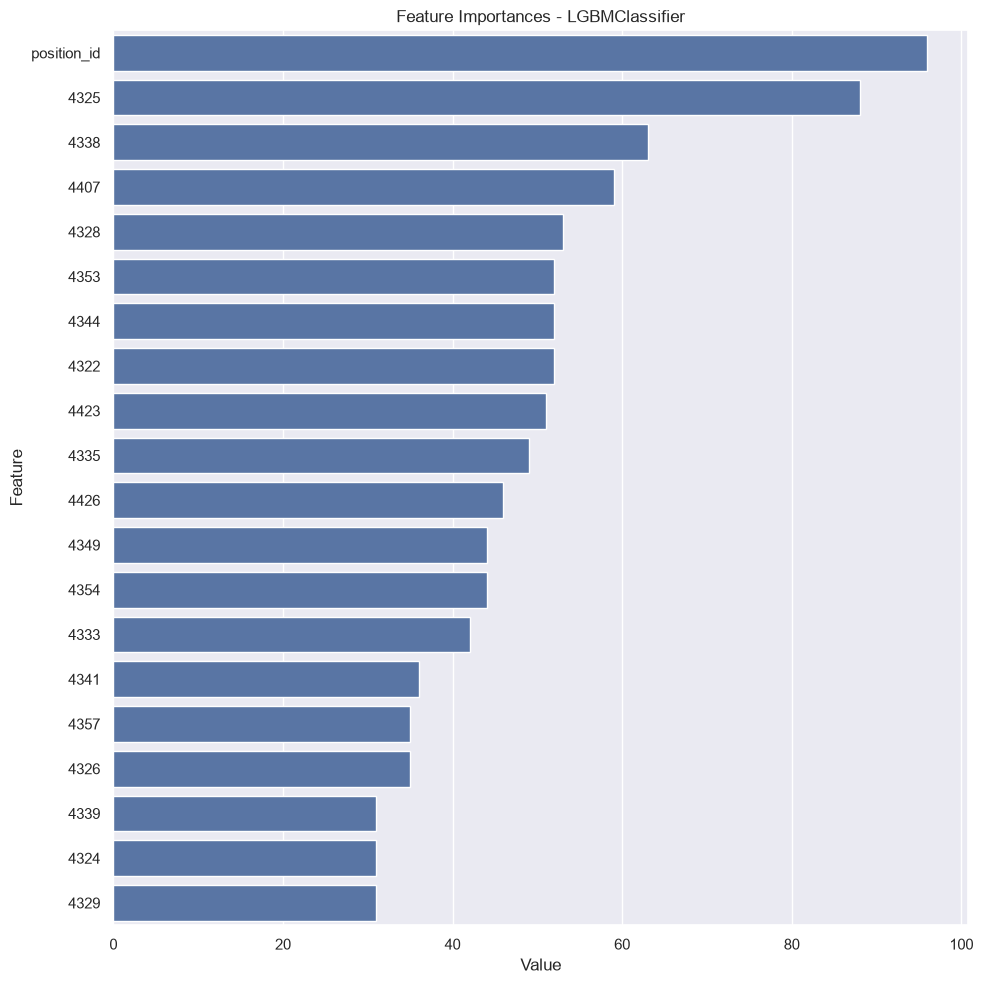

,Value,Feature
0,96,position_id
4,88,4325
13,63,4338
31,59,4407
7,53,4328
26,52,4353
19,52,4344
1,52,4322
33,51,4423
12,49,4335


In [16]:
def plot_importance(model, features, num=20, save=False):
    """
    Modelin bağımsız değişkenlere verdiği önemi yatay bar grafikte gösterir.
    Ağaç tabanlı modellerde feature_importances_ kullanılır.
    Doğrusal modellerde (Logistic Regression) katsayıların mutlak değeri alınır.
    """
    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_
    elif hasattr(model, "coef_"):
        importance = np.abs(model.coef_[0])
    else:
        print(f"{type(model).__name__} için 'importance' bilgisi bulunamadı.")
        return

    feature_imp = pd.DataFrame({
        "Value": importance,
        "Feature": features.columns
    }).sort_values("Value", ascending=False)

    plt.figure(figsize=(10, 10))
    sns.set(font_scale=1)
    sns.barplot(
        x="Value",
        y="Feature",
        data=feature_imp.iloc[:num]
    )
    plt.title(f"Feature Importances - {type(model).__name__}")
    plt.tight_layout()
    plt.show()

    if save:
        plt.savefig("importances.png")

    return feature_imp


# Nihai modeli tüm veri ile eğittikten sonra hangi scout özelliklerinin
# "highlighted" ayrımında daha çok işe yaradığına bakıyoruz.
importance_df = plot_importance(final_model, X, num=20)
importance_df.head(20)

LightGBM'de en yüksek önem **`position_id`** (96). Aynı puan forvette ve stoperde farklı okunur; pozisyon etiketi bu yüzden ayrımı taşıyor.

Ardından öne çıkan scout özellikleri: **4325, 4338, 4328, 4353, 4344, 4322**. Veride özelliklerin isimleri yok, yalnızca id'ler var; sıralama “hangi puan kartı highlighted ayrımında daha çok işe yarıyor?” sorusuna cevap veriyor. Alt sıradaki id'ler modele az katkı yaptığı için ileride sadeleştirmede aday olur.
